<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


<h1>Lab: Car Detection with Haar Classifiers</h1>


## Overview


In this lab, you will apply a pre-trained Haar cascade classifier to your uploaded car image to perform vehicle detection.


# Objectives


Haar Cascade is a machine learning method based on Haar wavelet to identify objects in an image or a video. We will use the [OpenCV](http://opencv.org/) library. It is based on the concept of features proposed by Paul Viola and Michael Jones in their paper "Rapid Object Detection using a Boosted Cascade of Simple Features".


## Table of Contents


This notebook is organized into the following sections:
        <ul>
            <li>[Install and Import Libraries](#Install-and-Import-Libraries) </li>
            <li>[Image Processing](#Image-Processing)</li>
            <li>[Practice Exercise - Upload your image](#Practice-Exercise---Upload-your-image) </li>
            </li>      
        </ul>
    </li>
</ul>


## Install and Import Libraries


In [1]:
!pip install opencv-python-headless
!pip install numpy pandas matplotlib  --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 120.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 50.2 MB/s eta 0:00:00:00:01


**Import important libraries and Define auxilary functions**


In [2]:
import urllib.request
import cv2
from matplotlib import pyplot as plt
%matplotlib inline

**Create a function that cleans up and displays the image:**

The `plt_show()` function is a utility used to visualize images in Jupyter notebooks or scripts using matplotlib. 

It supports both color and grayscale display formats. By default, OpenCV loads images in BGR color format, which needs to be converted to RGB for correct display with matplotlib. This function handles that conversion when gray=False. 

It also allows adding a title and customizing the display size. The gray=True flag enables viewing the image in grayscale, which is helpful when working with edge detection, object detection, or when inspecting single-channel data like masks or features. This utility is especially useful during data preprocessing, model evaluation, and debugging steps in computer vision tasks.


In [3]:
# Function to display images using matplotlib
def plt_show(image, title="", gray=False, size=(10, 10)):
    temp = image.copy()  # Make a copy to avoid altering the original image

    if not gray:
        # Convert image from BGR (OpenCV default) to RGB (matplotlib expects RGB)
        temp = cv2.cvtColor(temp, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=size)  # Set figure size
    plt.imshow(temp, cmap='gray' if gray else None)  # Display image; grayscale if 'gray=True'
    plt.title(title)  # Set the title above the image
    plt.axis("off")  # Hide axis ticks and labels for a cleaner look
    plt.show()  # Render the image


**Create a function to detect cars in an image**

This function detects cars in an input image using a pre-trained Haar cascade classifier. It first converts the image to grayscale, as Haar classifiers are designed to work on single-channel images.

It then applies detectMultiScale() to find car-like regions. To improve reliability, it filters the detections by choosing only the largest bounding box, assuming that the main subject (the car) dominates the image. 

After detecting, it draws a green rectangle around the car and displays the result using a helper function (plt_show). You can tweak the scaleFactor, minNeighbors, and size parameters to improve detection accuracy based on your input image resolution.


In [4]:
def detect_obj(image):
    # Make a copy of the original image to avoid drawing on the original
    img_copy = image.copy()
    
    # Convert the image to grayscale because Haar cascades work on single-channel images
    gray = cv2.cvtColor(img_copy, cv2.COLOR_BGR2GRAY)

    # Detect objects using Haar cascade with relaxed parameters
    cars = detector.detectMultiScale(
        gray,
        scaleFactor=1.05,  # Slightly finer scale steps for detecting objects at different sizes
        minNeighbors=2,    # Lower value increases sensitivity (may result in more false positives)
        minSize=(30, 30),  # Ignore very small detections
        maxSize=(700, 700) # Ignore very large detections
    )

    # If detections are found, keep only the largest one (assuming it's the main car)
    if len(cars) > 0:
        # Sort detections by area (width * height), descending
        cars = sorted(cars, key=lambda box: box[2] * box[3], reverse=True)
        # Keep only the largest bounding box to avoid multiple overlapping detections
        cars = [cars[0]]

    # Print the number of cars detected (after filtering)
    print(f"Detected: {len(cars)} car(s)")

    # Draw a green rectangle around the detected car(s)
    for (x, y, w, h) in cars:
        cv2.rectangle(img_copy, (x, y), (x + w, y + h), (0, 255, 0), 2)

    # Display the image with the detected car(s)
    plt_show(img_copy, title="Detected Car")


## Image Processing

You are preparing the environment for car detection by:

    Downloading the pre-trained Haar cascade XML for car detection.
    
    Creating a detector using OpenCV's CascadeClassifier.
    
    Loading a test image from a remote URL.
    
    Displaying the image using a custom plt_show() function.
    
    Detecting the object using detect_obj() function.


**Download Haar Cascade XML file from a remote URL**


Load pre-trained classifier from [andrewssobral](https://raw.githubusercontent.com/andrewssobral/vehicle_detection_haarcascades/master/cars.xml) git repository, training takes a long time but prediction is fast.


In [5]:
# Define the URL of the Haar Cascade file for car detection.
# This file contains a pre-trained classifier (feature patterns) for detecting cars.
haarcascade_url = 'https://raw.githubusercontent.com/andrewssobral/vehicle_detection_haarcascades/master/cars.xml'

# Define the local filename to save the downloaded XML file.
haar_name = "cars.xml"

# Download the XML file from the URL and save it locally as 'cars.xml'.
# urllib.request.urlretrieve() fetches the file from the internet.
urllib.request.urlretrieve(haarcascade_url, haar_name)


('cars.xml', <http.client.HTTPMessage at 0x7c8d1e3ccd70>)

**Get the detector using the `cv2.CascadeClassifier()` module on the pretrained dataset**


In [6]:
detector = cv2.CascadeClassifier(haar_name)

**Read a sample image**


In [7]:
# Define the URL of the sample image (a car on the road).
image_url = "https://s3.us.cloud-object-storage.appdomain.cloud/cf-courses-data/CognitiveClass/CV0101/Dataset/car-road-behind.jpg"

# Specify the name to save the downloaded image locally.
image_name = "car-road-behind.jpg"

# Download the image from the given URL and save it with the specified name.
urllib.request.urlretrieve(image_url, image_name)

# Load the downloaded image using OpenCV (reads image in BGR format by default).
image = cv2.imread(image_name)


**Plot the image**


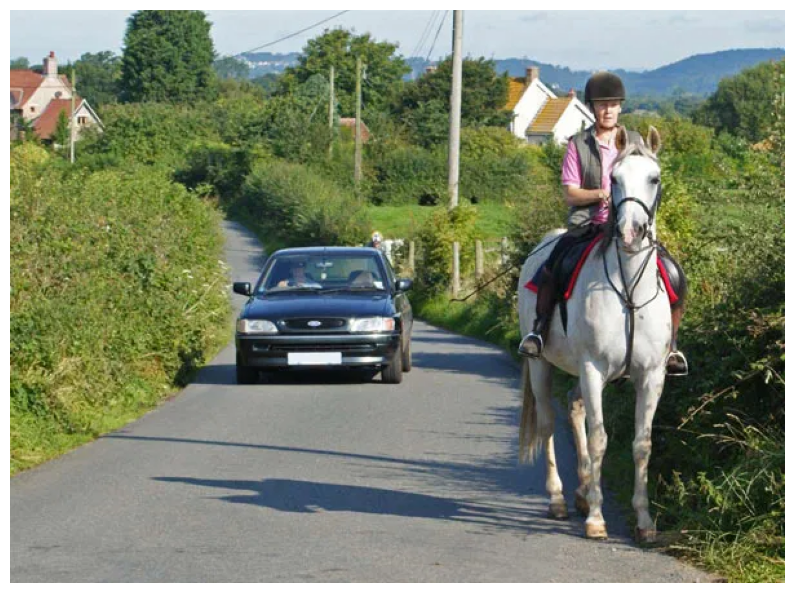

In [8]:
plt_show(image)

**Detect the object on loaded image**


Detected: 1 car(s)


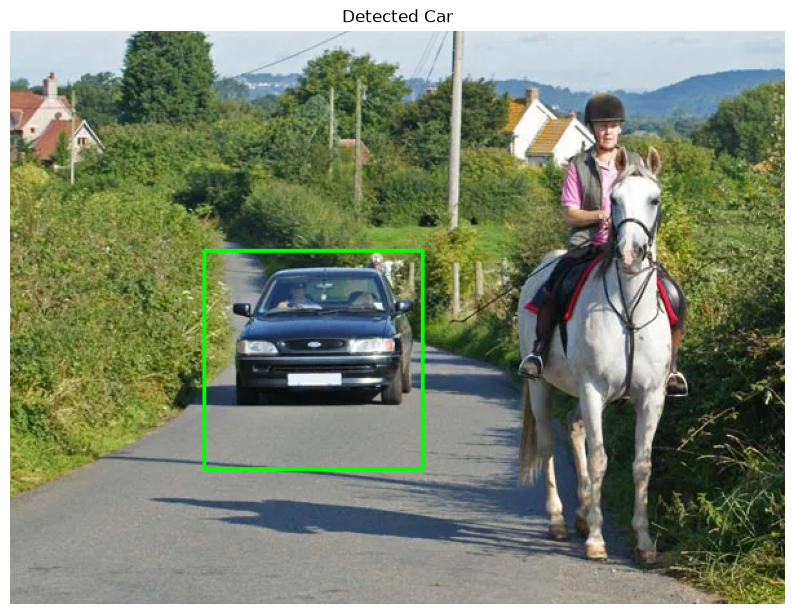

In [9]:
detect_obj(image)

# Practice Exercise - Upload your image


Upload your image and see if your car will be correctly detected.
<p><b>Instructions on how to upload an image:</b></p>
Use the upload button and upload the image from your local machine
<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images/instruction.png" width="300"  />
</center>


The image will now be in the directory in which you are working in. To read the image in a new cell, use the <code>cv2.imread</code>  function. For example, I uploaded <code>anothercar.jpg</code>  into my current working directory - <code>cv2.imread("anothercar.jpg")</code>.


<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images/instruction2.png" width="300"  />
</center>


Else use the below images to test.


In [10]:
!wget "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/h3EzuZiidvgdOxPA_yVVWg/car1.jpg"
!wget "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/eKnqJ2xWDdanVdLH6WgOmQ/car2.jpg"
!wget "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/JDjRn_0f5kx9DRT2xv_mew/nocar.jpg"

--2026-06-28 16:59:32--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/h3EzuZiidvgdOxPA_yVVWg/car1.jpg
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 8949 (8.7K) [image/jpeg]
Saving to: ‘car1.jpg’

car1.jpg            100%[===================>]   8.74K  --.-KB/s    in 0s      

2026-06-28 16:59:32 (32.6 MB/s) - ‘car1.jpg’ saved [8949/8949]

--2026-06-28 16:59:34--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/eKnqJ2xWDdanVdLH6WgOmQ/car2.jpg
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-obje

Replace your_uploaded_file below with the name of your image as seen in your directory. In case you are using the downloaded images given in the notebook then use as `car1.jpg` or `car2.jpg` or `nocar.jpg`


In [20]:
## replace "your_uploaded_file" with your file name
my_image = cv2.imread("car2.jpg")

In [21]:
if my_image is None:
    print("Error: image is empty or not loaded properly.")  


Run the Cascade classifier on your model to detect the object.


Detected: 1 car(s)


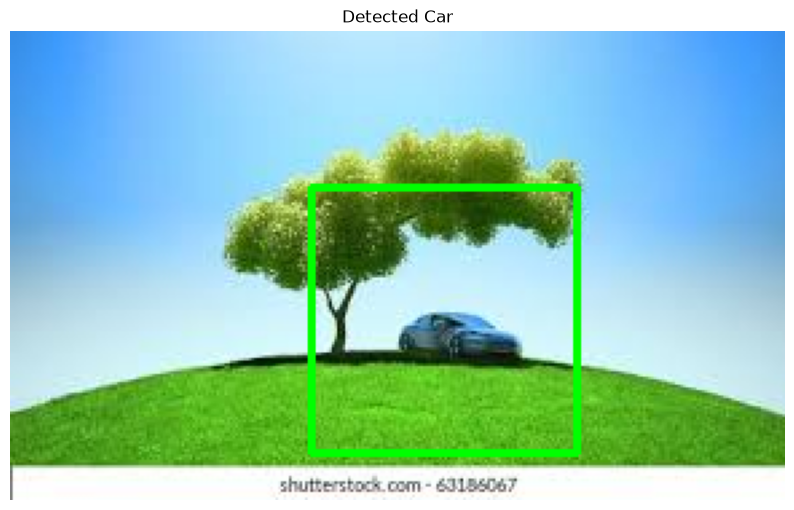

In [22]:
detect_obj(my_image)

### Congratulations! You've completed the Car Detection lab using Haar Cascade Classifiers.
You successfully applied a pre-trained model to detect vehicle in images using OpenCV.


<h2>Authors</h2>


<a href="https://www.linkedin.com/in/aije-egwaikhide/">Aije Egwaikhide</a> 

<a href="https://www.linkedin.com/in/nayefaboutayoun/" target="_blank">Nayef Abou Tayoun</a>

[Sathya Priya](https://www.linkedin.com/in/sathya-priya-06120a17a/) 


<!--<h2>Change Log</h2>-->


<!--<table>
    <tr>
        <th>Date (YYYY-MM-DD)</th>
        <th>Version</th>
        <th>Changed By</th>
        <th>Change Description</th>
    </tr>
    <tr>
        <td>2025-06-28</td>
        <td>1.1</td>
        <td>Sathya Priya</td>
        <td>Created and Converted the lab to JupyterCurrent notebook </td>
    </tr>
    <tr>
        <td>2021-04-09</td>
        <td>1.0</td>
        <td>Aije</td>
        <td>Updated to new template</td>
    </tr>
    <tr>
        <td>2021-03-02</td>
        <td>0.2</td>
        <td>Aije</td>
        <td>Updated code and instructions and added practice exercise</td>
    </tr>
    <tr>
        <td>2020-08-18</td>
        <td>0.1</td>
        <td>Nayef</td>
        <td>Created original version of the lab</td>
    </tr>
</table>
-->


<h3 align="center"> &#169; IBM Corporation. All rights reserved. <h3/>
